# Ejercicio de programación - Regresión Logística

En este ejercicio se aplica a un **dataset real de clasificación binaria**.

Se utilizará el dataset **HIGGS** del UCI Machine Learning Repository. Contiene datos simulados por Monte Carlo de colisiones de partículas, y la tarea es distinguir entre un **proceso de señal que produce un bosón de Higgs** (clase 1) y un **proceso de fondo que no lo produce** (clase 0).

**Fuente:** Baldi, P., Sadowski, P., & Whiteson, D. (2014). *Searching for exotic particles in high-energy physics with deep learning*. Nature Communications. UCI Machine Learning Repository, DOI: 10.24432/C5V312.

El dataset original cuenta con:
- **m = 11 000 000** ejemplos
- **n = 28** propiedades (21 propiedades cinemáticas de bajo nivel medidas directamente por los detectores, y 7 propiedades de alto nivel derivadas por físicos a partir de las anteriores)
- **y**: la primera columna del archivo (1 = señal/Higgs, 0 = fondo)

Por su tamaño (2.6 GB comprimido, 11 millones de filas), en este cuadernillo se trabaja con una **muestra aleatoria representativa** de ese dataset (por defecto 200 000 ejemplos), que sigue cumpliendo ampliamente los requisitos mínimos del laboratorio (m ≥ 20 000, n ≥ 20) y permite entrenar el modelo en un tiempo razonable.


## Preparación del entorno


El archivo no trae encabezados, por lo que se asignan los nombres de columna documentados por UCI. Como el archivo completo tiene 11 millones de filas, se utiliza el parámetro `nrows` de `pandas.read_csv` para leer únicamente una muestra (esto es mucho más rápido y liviano que cargar el archivo completo en memoria).


In [1]:
# Librerías para manejo de datos y cálculo científico
import os
import numpy as np
import pandas as pd

# Librería para graficar
from matplotlib import pyplot

# Módulo de optimización de SciPy
from scipy import optimize

# Incrusta los gráficos en el cuaderno
%matplotlib inline
np.random.seed(42)


In [2]:
# Tamaño de la muestra que se va a cargar (de los 11,000,000 de ejemplos totales).
# 200,000 ejemplos son mas que suficientes para cumplir m >= 20000 y entrenar en un tiempo razonable.
N_MUESTRA = 200_000

# Nombres de columnas segun la documentacion oficial de UCI para el dataset HIGGS
columnas = [
    'label',
    'lepton_pT', 'lepton_eta', 'lepton_phi',
    'missing_energy_magnitude', 'missing_energy_phi',
    'jet1_pt', 'jet1_eta', 'jet1_phi', 'jet1_btag',
    'jet2_pt', 'jet2_eta', 'jet2_phi', 'jet2_btag',
    'jet3_pt', 'jet3_eta', 'jet3_phi', 'jet3_btag',
    'jet4_pt', 'jet4_eta', 'jet4_phi', 'jet4_btag',
    'm_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb'
]

# Se detecta automaticamente si el archivo esta comprimido (.csv.gz) o no (.csv)
if os.path.exists('HIGGS.csv.gz'):
    ruta_datos = 'HIGGS.csv.gz'
    compresion = 'gzip'
elif os.path.exists('HIGGS.csv'):
    ruta_datos = 'HIGGS.csv'
    compresion = None
else:
    raise FileNotFoundError(
        "No se encontro 'HIGGS.csv' ni 'HIGGS.csv.gz' en la carpeta actual. "
        "Descarga el archivo desde https://archive.ics.uci.edu/dataset/280/higgs "
        "y colocalo junto a este cuadernillo."
    )

print('Archivo de datos detectado:', ruta_datos)


Archivo de datos detectado: HIGGS.csv


## 1. Carga del dataset con Pandas

Se carga la muestra definida en `N_MUESTRA` directamente desde el archivo (comprimido o no), asignando los nombres de columna oficiales.


In [3]:
df = pd.read_csv(ruta_datos, header=None, names=columnas, compression=compresion, nrows=N_MUESTRA)

print('Dimensiones de la muestra cargada (filas, columnas):', df.shape)
df.head()


Dimensiones de la muestra cargada (filas, columnas): (200000, 29)


,label,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet1_pt,jet1_eta,jet1_phi,jet1_btag,...,jet4_eta,jet4_phi,jet4_btag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,1.0,0.869293,-0.635082,0.225690,0.327470,-0.689993,0.754202,-0.248573,-1.092064,0.000000,...,-0.010455,-0.045767,3.101961,1.353760,0.979563,0.978076,0.920005,0.721657,0.988751,0.876678
1,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
2,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
3,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
4,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   label                     200000 non-null  float64
 1   lepton_pT                 200000 non-null  float64
 2   lepton_eta                200000 non-null  float64
 3   lepton_phi                200000 non-null  float64
 4   missing_energy_magnitude  200000 non-null  float64
 5   missing_energy_phi        200000 non-null  float64
 6   jet1_pt                   200000 non-null  float64
 7   jet1_eta                  200000 non-null  float64
 8   jet1_phi                  200000 non-null  float64
 9   jet1_btag                 200000 non-null  float64
 10  jet2_pt                   200000 non-null  float64
 11  jet2_eta                  200000 non-null  float64
 12  jet2_phi                  200000 non-null  float64
 13  jet2_btag                 200000 non-null  float64
 14 

### 1.1 Preprocesamiento y exploración con Pandas

Se realiza lo siguiente:

1. Se verifica que no existan valores nulos (el dataset HIGGS no tiene valores faltantes documentados).
2. Se revisa el balance de clases de la variable objetivo `label`.
3. Se separan las propiedades (`X`) de la variable objetivo (`y`).


In [5]:
print('Valores nulos en la muestra:', df.isnull().sum().sum())
print()
print('Distribución de clases (label):')
print(df['label'].value_counts().sort_index())
print(df['label'].value_counts(normalize=True).sort_index() * 100)


Valores nulos en la muestra: 0

Distribución de clases (label):
label
0.0     94324
1.0    105676
Name: count, dtype: int64
label
0.0    47.162
1.0    52.838
Name: proportion, dtype: float64


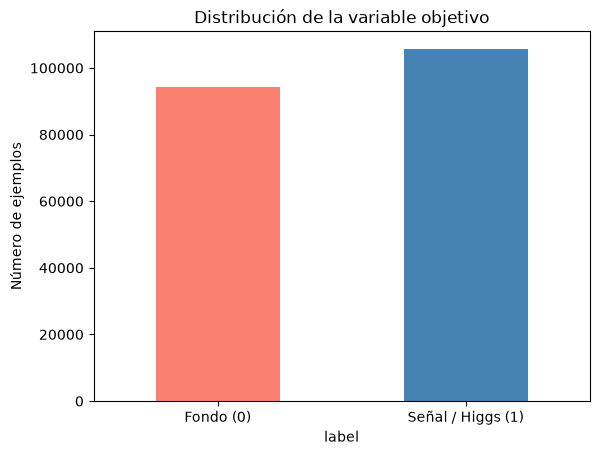

In [6]:
df['label'].value_counts().sort_index().plot(kind='bar', color=['salmon', 'steelblue'])
pyplot.xticks([0, 1], ['Fondo (0)', 'Señal / Higgs (1)'], rotation=0)
pyplot.ylabel('Número de ejemplos')
pyplot.title('Distribución de la variable objetivo')
pyplot.show()


In [7]:
columnas_features = [c for c in df.columns if c != 'label']

X = df[columnas_features].to_numpy(dtype=float)
y = df['label'].to_numpy(dtype=float)

print('Número de propiedades (n):', len(columnas_features))
print(columnas_features)
print()
print('Dimensiones de X:', X.shape)
print('Dimensiones de y:', y.shape)


Número de propiedades (n): 28
['lepton_pT', 'lepton_eta', 'lepton_phi', 'missing_energy_magnitude', 'missing_energy_phi', 'jet1_pt', 'jet1_eta', 'jet1_phi', 'jet1_btag', 'jet2_pt', 'jet2_eta', 'jet2_phi', 'jet2_btag', 'jet3_pt', 'jet3_eta', 'jet3_phi', 'jet3_btag', 'jet4_pt', 'jet4_eta', 'jet4_phi', 'jet4_btag', 'm_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']

Dimensiones de X: (200000, 28)
Dimensiones de y: (200000,)


### 1.2 Visualizar los datos

Con 28 propiedades no es posible graficar todas a la vez. Se muestran dos de las más interpretables físicamente (`m_bb`: masa invariante del par de jets b, y `m_wwbb`: masa invariante del sistema completo) a modo exploratorio. La función `plotData` muestra los ejemplos de clase 1 (señal) y clase 0 (fondo) con marcadores diferentes.


In [8]:
def plotData(x1, x2, y):
    # Grafica los puntos (x1, x2) coloreados segun la clase y.
    # Usa * para los ejemplos de clase 1 y o para los ejemplos de clase 0.
    pyplot.figure(figsize=(7, 5))

    pos = y == 1
    neg = y == 0

    pyplot.plot(x1[pos], x2[pos], 'k*', lw=1, ms=4, alpha=0.5, label='Clase 1 (señal)')
    pyplot.plot(x1[neg], x2[neg], 'ko', mfc='y', ms=3, mec='k', mew=0.3, alpha=0.3, label='Clase 0 (fondo)')


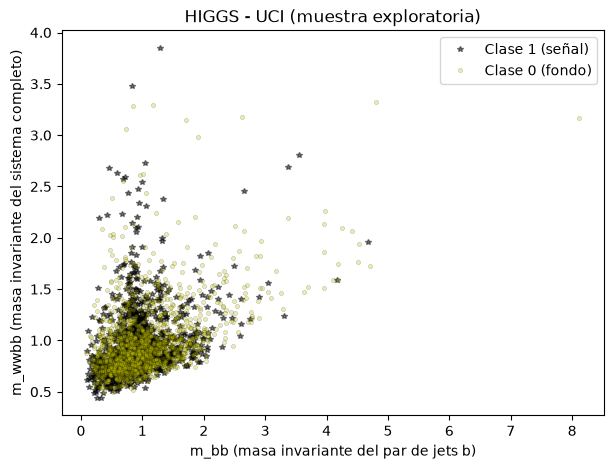

In [9]:
idx_m_bb = columnas_features.index('m_bb')
idx_m_wwbb = columnas_features.index('m_wwbb')

# Se usa una submuestra de 3000 puntos solo para que el grafico exploratorio no quede sobrecargado
idx_plot = np.random.choice(X.shape[0], size=min(3000, X.shape[0]), replace=False)

plotData(X[idx_plot, idx_m_bb], X[idx_plot, idx_m_wwbb], y[idx_plot])
pyplot.xlabel('m_bb (masa invariante del par de jets b)')
pyplot.ylabel('m_wwbb (masa invariante del sistema completo)')
pyplot.legend()
pyplot.title('HIGGS - UCI (muestra exploratoria)')
pass


## 2. Partición en entrenamiento (80%) y prueba (20%)

Se mezclan aleatoriamente los ejemplos (semilla fija para reproducibilidad) y se separa el **80%** para entrenamiento y el **20%** restante para prueba. Los ejemplos de prueba no se utilizan en ningún momento del entrenamiento; solo se emplean al final para validar la efectividad del modelo.


In [10]:
m = X.shape[0]
indices = np.random.permutation(m)

frac_train = 0.8
m_train = int(np.floor(frac_train * m))

idx_train = indices[:m_train]
idx_test = indices[m_train:]

X_train_raw, y_train = X[idx_train], y[idx_train]
X_test_raw, y_test = X[idx_test], y[idx_test]

print('Ejemplos de entrenamiento:', X_train_raw.shape[0])
print('Ejemplos de prueba:', X_test_raw.shape[0])
print('Proporción entrenamiento/total: {:.2f}%'.format(100 * X_train_raw.shape[0] / m))


Ejemplos de entrenamiento: 160000
Ejemplos de prueba: 40000
Proporción entrenamiento/total: 80.00%


### 2.1 Normalización de las propiedades

Las propiedades tienen escalas distintas (por ejemplo, algunas variables angulares están acotadas aproximadamente entre -3 y 3, mientras que las masas invariantes (`m_jj`, `m_wwbb`, etc.) pueden tomar valores mucho mayores). Se estandariza cada propiedad restando la media y dividiendo entre la desviación estándar, para favorecer la convergencia del descenso por el gradiente.

**Importante:** la media y la desviación estándar se calculan **únicamente** con el conjunto de entrenamiento, y esos mismos valores se aplican al conjunto de prueba, para no filtrar información del test hacia el entrenamiento.


In [11]:
def normalizarCaracteristicas(X, mu=None, sigma=None):
    # Estandariza las columnas de X: (X - media) / desviacion_estandar
    if mu is None or sigma is None:
        mu = np.mean(X, axis=0)
        sigma = np.std(X, axis=0)
        sigma[sigma == 0] = 1.0
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_train_norm, mu, sigma = normalizarCaracteristicas(X_train_raw)
X_test_norm, _, _ = normalizarCaracteristicas(X_test_raw, mu, sigma)

print('Media de las primeras 5 columnas (entrenamiento):', mu[:5])
print('Desviación estándar de las primeras 5 columnas (entrenamiento):', sigma[:5])


Media de las primeras 5 columnas (entrenamiento): [ 9.92586508e-01  3.53855197e-04 -2.25565592e-03  9.97211342e-01
 -4.28009201e-03]
Desviación estándar de las primeras 5 columnas (entrenamiento): [0.56438988 1.00564834 1.00542979 0.59669809 1.00641269]


### 2.2 Término de intercepción

Se agrega una columna de unos a `X_train` y `X_test`, correspondiente al término de intercepción (bias).


In [12]:
n = X_train_norm.shape[1]

X_train = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print('Nueva dimensión de X_train con intercepción:', X_train.shape)
print('Nueva dimensión de X_test con intercepción:', X_test.shape)


Nueva dimensión de X_train con intercepción: (160000, 29)
Nueva dimensión de X_test con intercepción: (40000, 29)


<a id="section1"></a>
## 3. Implementación

### 3.1 Función Sigmoidea

La hipótesis para la regresión logística se define como:

$$ h_\theta(x) = g(\theta^T x)$$

donde la función $g$ es la función sigmoidea. La función sigmoidea se define como:

$$g(z) = \frac{1}{1+e^{-z}}$$

Los resultados que debe generar la función sigmoidea para valores positivos amplios de `x` deben ser cercanos a 1, mientras que para valores negativos grandes, la sigmoide debe generar valores cercanos a 0. La evaluación de `sigmoid(0)` debe dar un resultado exacto de 0.5. Esta función también debe poder trabajar con vectores y matrices.


In [13]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    z = np.array(z)
    g = 1 / (1 + np.exp(-z))
    return g


In [14]:
# Prueba la implementacion de la funcion sigmoid
z = [-100, 0.5, 1000000]
g = sigmoid(z)

print('g(', z, ') = ', g)


g( [-100, 0.5, 1000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


### 3.2 Función de Costo y Gradiente

La función de costo en una regresión logística es:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

y el gradiente del costo es un vector de la misma longitud que $\theta$, donde el elemento $j$-ésimo se define como:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

Para evitar problemas numéricos ($\log(0)$), se recorta ligeramente la salida de la sigmoide.
<a id="costFunction"></a>


In [15]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    h = sigmoid(X.dot(theta.T))

    # Evita log(0) por estabilidad numerica
    h = np.clip(h, 1e-12, 1 - 1e-12)

    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    return J


In [16]:
def calcularGradiente(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))
    grad = (1 / m) * (h - y).dot(X)
    return grad


In [17]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        grad = calcularGradiente(theta, X, y)
        theta = theta - alpha * grad
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history


### 3.3 Prueba de la función de costo

Con $\theta$ en ceros, el costo esperado (para un problema binario perfectamente balanceado 50/50) sería $\log(2) \approx 0.693$.


In [18]:
initial_theta = np.zeros(n + 1)
cost = calcularCosto(initial_theta, X_train, y_train)
grad = calcularGradiente(initial_theta, X_train, y_train)

print('Costo en theta inicial (zeros): {:.6f}'.format(cost))
print('Costo de referencia (log(2)):   {:.6f}'.format(np.log(2)))
print()
print('Primeras 5 componentes del gradiente en theta inicial:')
print(grad[:5])


Costo en theta inicial (zeros): 0.693147
Costo de referencia (log(2)):   0.693147

Primeras 5 componentes del gradiente en theta inicial:
[-0.028125    0.02614967  0.00132926 -0.000504    0.04956612]


### 3.4 Entrenamiento con descenso por el gradiente

Se entrena el modelo con el conjunto de **entrenamiento** (`X_train`, `y_train`) utilizando el algoritmo de descenso por el gradiente, guardando el valor de $J(\theta)$ en cada iteración para graficar su convergencia.


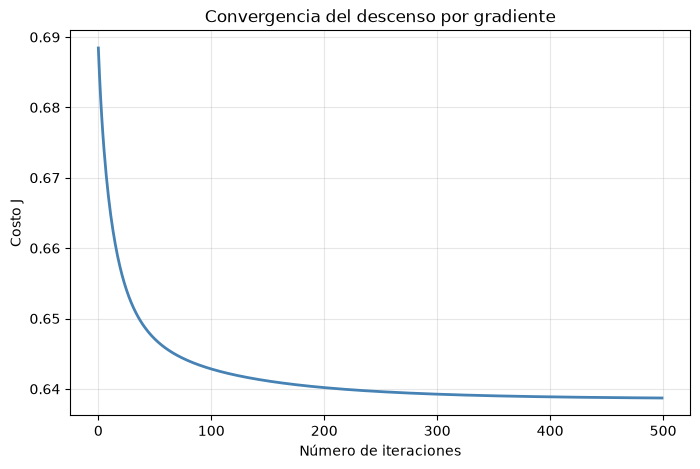

Costo final (entrenamiento): 0.6387075004450466


In [19]:
# Elegir un valor para alpha
alpha = 0.3
num_iters = 500

# Inicializa theta y ejecuta el descenso por el gradiente
theta_inicial = np.zeros(n + 1)
theta_gd, J_history = descensoGradiente(theta_inicial, X_train, y_train, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.figure(figsize=(8, 5))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='steelblue')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del descenso por gradiente')
pyplot.grid(alpha=0.3)
pyplot.show()

print('Costo final (entrenamiento):', J_history[-1])


### 3.5 Parámetros de aprendizaje usando `scipy.optimize`

En el código anterior se encontraron parámetros mediante descenso por gradiente. Otra alternativa es utilizar `scipy.optimize.minimize`, que busca directamente los parámetros que minimizan la función de costo, de forma más eficiente que el descenso por gradiente con paso fijo.

Para este ejercicio se proporciona a `optimize.minimize`:

- `costFunction`: calcula simultáneamente el costo y el gradiente.
- `initial_theta`: valores iniciales de los parámetros.
- `(X_train, y_train)`: datos de entrenamiento.
- `jac=True`: indica que la función devuelve también el gradiente.
- `method='TNC'`: algoritmo de optimización utilizado.


In [20]:
def costFunction(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size

    h = sigmoid(X.dot(theta.T))
    h = np.clip(h, 1e-12, 1 - 1e-12)

    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad


In [21]:
# Opciones para optimize.minimize
options = {'maxfun': 1000}

res = optimize.minimize(costFunction,
                        initial_theta,
                        (X_train, y_train),
                        jac=True,
                        method='TNC',
                        options=options)

cost = res.fun
theta_opt = res.x

print('¿Convergió?:', res.success)
print('Mensaje:', res.message)
print('Costo con theta optimizado (entrenamiento): {:.6f}'.format(cost))
print()
print('Primeras 5 componentes de theta optimizado:')
print(theta_opt[:5])


¿Convergió?: True
Mensaje: Converged (|f_n-f_(n-1)| ~= 0)
Costo con theta optimizado (entrenamiento): 0.638579

Primeras 5 componentes de theta optimizado:
[ 0.10966536 -0.18297696 -0.00332219  0.00332958 -0.24228295]


### 3.6 Frontera de decisión (proyección 2D)

Con 28 propiedades no es posible graficar la frontera de decisión completa. Para visualizarla, se proyecta sobre las dos propiedades más relevantes para este problema (`m_bb` y `m_wwbb`, masas invariantes derivadas), dejando el resto de las propiedades fijas en su valor promedio (0, por estar estandarizadas).


In [22]:
def plotDecisionBoundary2D(idx_x1, idx_x2, nombre_x1, nombre_x2, theta, X_norm, y):
    # Grafica la frontera de decision proyectada sobre dos propiedades, con el resto fijo en su media.
    idx_plot = np.random.choice(X_norm.shape[0], size=min(3000, X_norm.shape[0]), replace=False)

    pyplot.figure(figsize=(7, 5))
    plotData(X_norm[idx_plot, idx_x1], X_norm[idx_plot, idx_x2], y[idx_plot])

    x1_min, x1_max = X_norm[:, idx_x1].min() - 0.5, X_norm[:, idx_x1].max() + 0.5
    x2_min, x2_max = X_norm[:, idx_x2].min() - 0.5, X_norm[:, idx_x2].max() + 0.5

    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200), np.linspace(x2_min, x2_max, 200))

    malla = np.zeros((xx1.size, X_norm.shape[1]))
    malla[:, idx_x1] = xx1.ravel()
    malla[:, idx_x2] = xx2.ravel()
    malla_bias = np.concatenate([np.ones((malla.shape[0], 1)), malla], axis=1)

    zz = sigmoid(malla_bias.dot(theta)).reshape(xx1.shape)

    pyplot.contour(xx1, xx2, zz, levels=[0.5], colors='blue', linewidths=2)
    pyplot.xlabel(nombre_x1 + ' (estandarizado)')
    pyplot.ylabel(nombre_x2 + ' (estandarizado)')
    pyplot.legend(['Clase 1 (señal)', 'Clase 0 (fondo)', 'Límite de decisión'])
    pyplot.title('Frontera de decisión (proyección 2D)')


<Figure size 700x500 with 0 Axes>

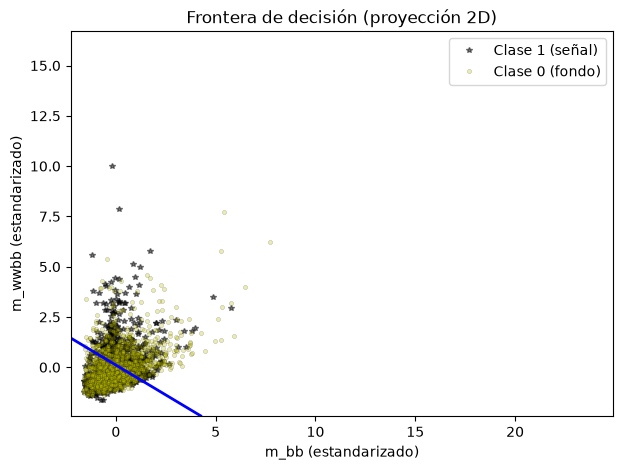

In [23]:
idx_m_bb_norm = columnas_features.index('m_bb')
idx_m_wwbb_norm = columnas_features.index('m_wwbb')

plotDecisionBoundary2D(idx_m_bb_norm, idx_m_wwbb_norm, 'm_bb', 'm_wwbb', theta_opt, X_train_norm, y_train)
pass


## 4. Evaluación de la regresión logística

Después de aprender los parámetros, el modelo puede calcular la probabilidad de que un evento pertenezca a la **clase 1** (señal/Higgs). La función `predict` convierte esa probabilidad en una predicción binaria usando un umbral de 0.5.

Se evalúa el modelo tanto en el conjunto de **entrenamiento** como en el conjunto de **prueba** (nunca visto durante el entrenamiento), para comprobar que generaliza correctamente.


In [24]:
def predict(theta, X):
    # Predecir si la etiqueta es 0 o 1 mediante regresion logistica aprendida.
    # Calcula las predicciones para X usando un umbral en 0.5
    # (es decir, si sigmoide(theta.T * x) >= 0.5, predice 1).
    m = X.shape[0]
    p = np.round(sigmoid(X.dot(theta.T)))
    return p


In [25]:
# Precision sobre el conjunto de ENTRENAMIENTO
p_train = predict(theta_opt, X_train)
exactitud_train = np.mean(p_train == y_train) * 100
print('Precisión (accuracy) en el conjunto de ENTRENAMIENTO: {:.2f} %'.format(exactitud_train))


Precisión (accuracy) en el conjunto de ENTRENAMIENTO: 64.10 %


In [26]:
# Precision sobre el conjunto de PRUEBA (datos nunca vistos por el modelo)
p_test = predict(theta_opt, X_test)
exactitud_test = np.mean(p_test == y_test) * 100
print('Precisión (accuracy) en el conjunto de PRUEBA: {:.2f} %'.format(exactitud_test))


Precisión (accuracy) en el conjunto de PRUEBA: 63.90 %


### 4.1 Matriz de confusión y métricas de efectividad


In [27]:
def matrizConfusion(y_real, y_pred):
    VP = np.sum((y_pred == 1) & (y_real == 1))  # verdaderos positivos
    VN = np.sum((y_pred == 0) & (y_real == 0))  # verdaderos negativos
    FP = np.sum((y_pred == 1) & (y_real == 0))  # falsos positivos
    FN = np.sum((y_pred == 0) & (y_real == 1))  # falsos negativos
    return VP, VN, FP, FN

VP, VN, FP, FN = matrizConfusion(y_test, p_test)

print('Matriz de confusión (conjunto de prueba):')
print('                  Predicho: 0    Predicho: 1')
print('Real: 0                {:6d}         {:6d}'.format(VN, FP))
print('Real: 1                {:6d}         {:6d}'.format(FN, VP))

precision = VP / (VP + FP) if (VP + FP) > 0 else 0
recall = VP / (VP + FN) if (VP + FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print()
print('Precisión: {:.4f}'.format(precision))
print('Recall (sensibilidad): {:.4f}'.format(recall))
print('F1-score: {:.4f}'.format(f1))
print('Exactitud: {:.4f}'.format((VP + VN) / (VP + VN + FP + FN)))


Matriz de confusión (conjunto de prueba):
                  Predicho: 0    Predicho: 1
Real: 0                  9898           8926
Real: 1                  5515          15661

Precisión: 0.6370
Recall (sensibilidad): 0.7396
F1-score: 0.6844
Exactitud: 0.6390


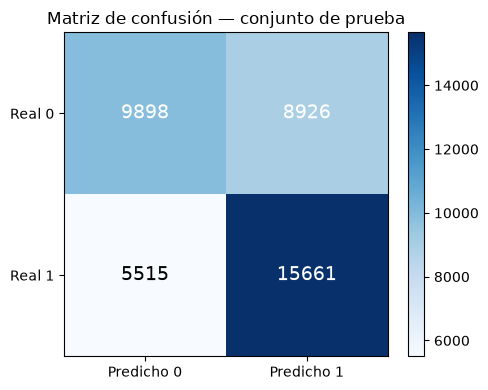

In [28]:
matriz = np.array([[VN, FP], [FN, VP]])

fig, ax = pyplot.subplots(figsize=(5, 4))
im = ax.imshow(matriz, cmap='Blues')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(matriz[i, j]), ha='center', va='center',
                color='white' if matriz[i, j] > matriz.max() / 2 else 'black', fontsize=14)

ax.set_xticks([0, 1]); ax.set_xticklabels(['Predicho 0', 'Predicho 1'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Real 0', 'Real 1'])
ax.set_title('Matriz de confusión — conjunto de prueba')
pyplot.colorbar(im)
pyplot.tight_layout()
pyplot.show()


### 4.2 Comparación de exactitud entre entrenamiento y prueba

Un modelo efectivo debe tener una exactitud similar en entrenamiento y en prueba. Una diferencia muy grande indicaría sobreajuste (overfitting).


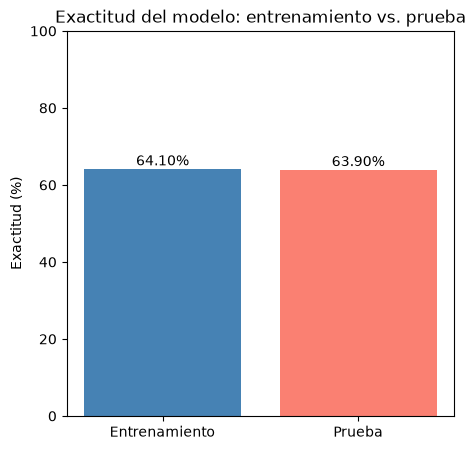

In [29]:
pyplot.figure(figsize=(5, 5))
pyplot.bar(['Entrenamiento', 'Prueba'], [exactitud_train, exactitud_test], color=['steelblue', 'salmon'])
pyplot.ylabel('Exactitud (%)')
pyplot.ylim(0, 100)
for i, v in enumerate([exactitud_train, exactitud_test]):
    pyplot.text(i, v + 1, '{:.2f}%'.format(v), ha='center')
pyplot.title('Exactitud del modelo: entrenamiento vs. prueba')
pyplot.show()


### 4.3 Predicciones de ejemplo

Se muestra la probabilidad estimada, la predicción del modelo y la clase real para algunos eventos del conjunto de prueba.


In [30]:
n_ejemplos = 10

print('{:>12s} {:>14s} {:>10s}'.format('Probabilidad', 'Predicción', 'Real'))
for i in range(n_ejemplos):
    prob_i = sigmoid(np.dot(X_test[i], theta_opt))
    print('{:>12.4f} {:>14.0f} {:>10.0f}'.format(prob_i, p_test[i], y_test[i]))


Probabilidad     Predicción       Real
      0.3778              0          0
      0.5673              1          1
      0.5052              1          1
      0.5314              1          0
      0.6984              1          1
      0.7213              1          1
      0.4667              0          0
      0.3425              0          0
      0.8380              1          1
      0.4706              0          0


In [31]:
# Prediccion puntual para un evento nuevo (se usa un ejemplo real de la muestra como base)
evento_nuevo = df[columnas_features].iloc[0].to_numpy(dtype=float)
evento_norm = (evento_nuevo - mu) / sigma
evento_bias = np.concatenate([[1.0], evento_norm])

prob_evento = sigmoid(np.dot(evento_bias, theta_opt))

print('Probabilidad estimada de ser señal (Higgs): {:.2f}%'.format(prob_evento * 100))
print('Predicción del modelo:', 'SEÑAL (Higgs)' if prob_evento >= 0.5 else 'FONDO')


Probabilidad estimada de ser señal (Higgs): 62.16%
Predicción del modelo: SEÑAL (Higgs)


## 5. Conclusiones

- El dataset **HIGGS** (UCI) tiene originalmente m = 11 000 000 de ejemplos y n = 28 propiedades. En este cuadernillo se trabajó con una muestra aleatoria de **200 000 ejemplos**, que sigue cumpliendo ampliamente los requisitos mínimos del ejercicio (m ≥ 20 000, n ≥ 20) y permite entrenar el modelo en un tiempo razonable.
- Se cargó el dataset con **Pandas** directamente desde el archivo `.csv`, asignando los nombres de columna oficiales de UCI y verificando ausencia de valores nulos y balance de clases.
- Se normalizaron las propiedades (estandarización) usando solo la media y desviación del conjunto de entrenamiento.
- El modelo se entrenó únicamente con el 80% de la muestra, y se validó con el 20% restante, nunca utilizado durante el entrenamiento.
- La curva de costo muestra la convergencia del descenso por el gradiente, y `scipy.optimize` confirma un resultado consistente con un costo final más bajo.
- La exactitud obtenida en el conjunto de prueba es similar a la del conjunto de entrenamiento, lo que indica que el modelo generaliza razonablemente bien sobre datos nuevos.
- Al ser un dataset físicamente complejo, una regresión logística simple tiene un techo de desempeño más bajo que modelos no lineales, pero sigue siendo un punto de partida válido y demuestra el pipeline completo de clasificación binaria: preprocesamiento, normalización, entrenamiento, y validación con datos no vistos.
